# Profiling notebook — where an LLM fine-tuning job spends its time

ME344 final project, Option 2. Companion to `README.md`; this notebook is the
working surface behind the report.

**It reads `results/*.json` and computes everything shown below.** No figure here is
transcribed from the report, and no number is typed in by hand — if a record is
missing a field, the corresponding cell says so rather than filling the gap.

The workload is a LoRA fine-tune of Qwen3 on **CodiEsp** (Spanish clinical case
reports annotated with ICD-10 diagnosis codes, CC-BY 4.0), run through one
JAX/XLA code path on three backends:

| Backend | Hardware | Host arch |
|---|---|---|
| CPU | 32-core x86_64, 31 GiB (`hpcc-cluster-39`) | x86_64 |
| GPU | NVIDIA GH200 480 GB (`stanford-pilot`) | ARM64 Grace |
| TPU | TPU v5e 2×4, 8 chips (`class-tpu-cluster-west4`) | x86_64 |

In [1]:
import json, glob, os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "profiling" else Path.cwd()
RESULTS = REPO / "results"

ORANGE, INK, GREY = "#E8590C", "#1A1A1A", "#9CA3AF"
BACKEND_COLOR = {"cpu": "#6B7280", "gpu": ORANGE, "tpu": "#0EA5E9"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.edgecolor": "#D1D5DB",
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": GREY, "ytick.color": GREY, "axes.grid": True,
    "grid.color": "#EEF0F2", "grid.linewidth": 0.8,
})

records = {}
for f in sorted(glob.glob(str(RESULTS / "*.json"))):
    if Path(f).stem == "analysis":
        continue
    d = json.loads(Path(f).read_text())
    records[d["run_id"]] = d

print(f"{len(records)} measurement records")
for rid, d in records.items():
    print(f"  {d['status']:6} {rid}")

9 measurement records
  ok     cpu-x86-32c-0p6b-bs1-seq1024
  ok     gpu-gh200-0p6b-bs1-seq1024
  ok     tpu-v5e8-bs1-seq1024-filecache-0p6b
  ok     tpu-v5e8-bs16-seq1024-filecache
  oom    tpu-v5e8-bs32-seq1024-filecache
  ok     tpu-v5e8-bs8-seq1024-filecache
  ok     tpu-v5e8-bs8-seq1024
  ok     tpu-v5e8-bs8-seq2048-filecache
  ok     tpu-v5e8-bs8-seq512-filecache


## 1 — Read the contract before trusting a record

`docs/metrics-contract.md` fixes the schema every run writes against. Two fields
decide whether a record may be plotted at all:

* `status` — `ok`, `oom`, `error` or `timeout`
* `notes` — free text the instrumentation writes about *its own* reliability

A passing status is **not** sufficient. One discarded run reported 93 µs per step
and 11 M tokens/s — physically impossible — while carrying `status: "ok"`. What
caught it was the note the telemetry module wrote about possibly having timed
dispatch rather than completion. The cell below applies that rule mechanically.

In [2]:
SUSPECT = ("stale buffer", "indicative", "could not be captured", "may have been")

def usable(d):
    """A record is plottable only if it passed AND its own notes raise no doubt."""
    if d["status"] != "ok":
        return False, d["status"]
    note = (d.get("notes") or "")
    hit = next((s for s in SUSPECT if s in note), None)
    return (False, f"notes: {hit}") if hit else (True, "")

for rid, d in records.items():
    ok, why = usable(d)
    print(f"  {'PLOT ' if ok else 'HOLD '} {rid:44} {why}")

  PLOT  cpu-x86-32c-0p6b-bs1-seq1024                 
  PLOT  gpu-gh200-0p6b-bs1-seq1024                   
  PLOT  tpu-v5e8-bs1-seq1024-filecache-0p6b          
  PLOT  tpu-v5e8-bs16-seq1024-filecache              
  HOLD  tpu-v5e8-bs32-seq1024-filecache              oom
  PLOT  tpu-v5e8-bs8-seq1024-filecache               
  PLOT  tpu-v5e8-bs8-seq1024                         
  PLOT  tpu-v5e8-bs8-seq2048-filecache               
  PLOT  tpu-v5e8-bs8-seq512-filecache                


## 2 — Wall-clock decomposition: the headline

Total runtime is a useless number on its own. Each run reports six phases, and the
question the project exists to answer is what fraction of them is arithmetic.

In [3]:
PHASES = ["submit_to_running_s", "image_pull_s", "model_load_s",
          "compile_s", "steady_state_s", "checkpoint_write_s", "other_s"]
LABEL = {"submit_to_running_s": "scheduling", "image_pull_s": "image pull",
         "model_load_s": "checkpoint load", "compile_s": "XLA compile",
         "steady_state_s": "steady-state steps", "checkpoint_write_s": "checkpoint write",
         "other_s": "other"}
SEG_COLOR = ["#CBD5E1", "#94A3B8", "#F59E0B", "#EF4444", ORANGE, "#64748B", "#E2E8F0"]

base = records["tpu-v5e8-bs8-seq1024"]
p = base["phases"]
total = p["total_wall_s"]

print(f"{base['run_id']}  —  {total:.1f} s total\n")
for k in PHASES:
    v = p.get(k) or 0.0
    print(f"  {LABEL[k]:22} {v:8.1f} s   {100*v/total:5.1f} %")

compute_pct = p["steady_state_s"] / total * 100
print(f"\n  arithmetic: {compute_pct:.1f} % of wall clock")
print(f"  overhead:   {100-compute_pct:.1f} %")

tpu-v5e8-bs8-seq1024  —  732.9 s total

  scheduling                114.0 s    15.6 %
  image pull                  0.0 s     0.0 %
  checkpoint load           235.1 s    32.1 %
  XLA compile                70.7 s     9.6 %
  steady-state steps        208.7 s    28.5 %
  checkpoint write            2.2 s     0.3 %
  other                     102.2 s    13.9 %

  arithmetic: 28.5 % of wall clock
  overhead:   71.5 %


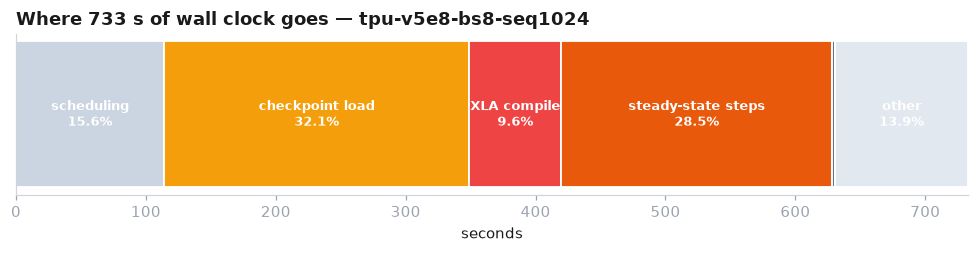

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.4))
left = 0.0
for k, c in zip(PHASES, SEG_COLOR):
    v = p.get(k) or 0.0
    if v <= 0:
        continue
    ax.barh(0, v, left=left, color=c, edgecolor="white", linewidth=1.2)
    if v / total > 0.06:
        ax.text(left + v/2, 0, f"{LABEL[k]}\n{100*v/total:.1f}%", ha="center",
                va="center", fontsize=8.5, color="white", fontweight="bold")
    left += v
ax.set_xlim(0, total); ax.set_yticks([]); ax.set_xlabel("seconds")
ax.set_title(f"Where {total:.0f} s of wall clock goes — {base['run_id']}", loc="left",
             fontweight="bold")
ax.grid(False)
plt.tight_layout(); plt.show()

## 3 — The like-for-like comparison

All three backends meet at **Qwen3-0.6B**, batch 1, sequence 1024. That is the only
configuration where the comparison is honest: same script, same corpus, same flags,
one JAX program lowered by XLA to three different targets.

In [5]:
TRIO = {
    "CPU 32-core":  "cpu-x86-32c-0p6b-bs1-seq1024",
    "GPU GH200":    "gpu-gh200-0p6b-bs1-seq1024",
    "TPU v5e 2x4":  "tpu-v5e8-bs1-seq1024-filecache-0p6b",
}
rows, steps = [], {}
for label, rid in TRIO.items():
    d = records[rid]; s, m = d["steady"], d["memory"]
    steps[label] = s["median_step_s"]
    rows.append((label, s["median_step_s"], s["tokens_per_s"], m["peak_pct"],
                 (d["utilization"] or {}).get("mean_pct")))

cpu_step = steps["CPU 32-core"]
print(f"{'':14}{'step_s':>10}{'tok/s':>12}{'peak mem':>10}{'util':>9}{'speedup':>10}")
for label, st, tok, mem, util in rows:
    u = f"{util:.2f} %" if util is not None else "n/a"
    print(f"{label:14}{st:10.4f}{tok:12,.0f}{mem:9.1f} %{u:>9}{cpu_step/st:9.1f}x")

delta = abs(steps["GPU GH200"] - steps["TPU v5e 2x4"]) / steps["TPU v5e 2x4"] * 100
print(f"\nGPU vs TPU step-time difference: {delta:.2f} %  "
      f"(1 Hopper chip against 8 v5e chips)")

                  step_s       tok/s  peak mem     util   speedup
CPU 32-core      18.9899          54     66.1 %  44.27 %      1.0x
GPU GH200         0.0798      12,834      5.0 %   1.59 %    238.0x
TPU v5e 2x4       0.0800      12,804      7.3 %      n/a    237.5x

GPU vs TPU step-time difference: 0.23 %  (1 Hopper chip against 8 v5e chips)


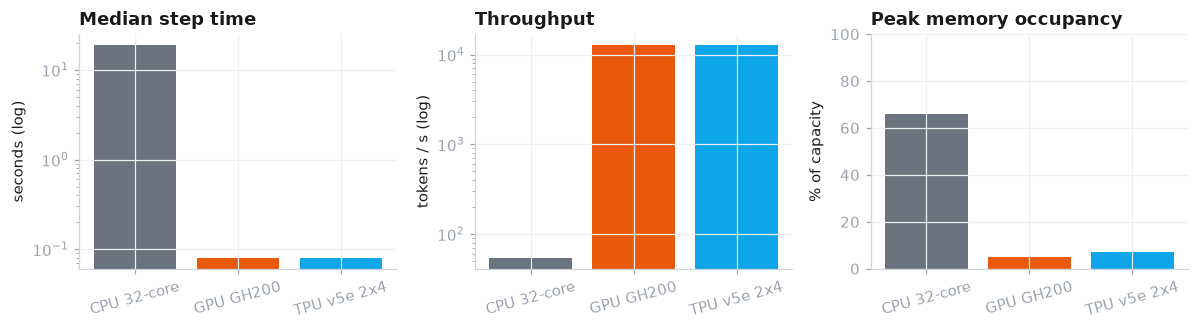

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
labels = [r[0] for r in rows]
colors = [BACKEND_COLOR["cpu"], BACKEND_COLOR["gpu"], BACKEND_COLOR["tpu"]]

axes[0].bar(labels, [r[1] for r in rows], color=colors)
axes[0].set_yscale("log"); axes[0].set_ylabel("seconds (log)")
axes[0].set_title("Median step time", loc="left", fontweight="bold")

axes[1].bar(labels, [r[2] for r in rows], color=colors)
axes[1].set_yscale("log"); axes[1].set_ylabel("tokens / s (log)")
axes[1].set_title("Throughput", loc="left", fontweight="bold")

axes[2].bar(labels, [r[3] for r in rows], color=colors)
axes[2].set_ylabel("% of capacity"); axes[2].set_ylim(0, 100)
axes[2].set_title("Peak memory occupancy", loc="left", fontweight="bold")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.show()

Two readings, and the second is the one worth carrying:

1. **One GH200 matches an eight-chip v5e slice.** Not eight times slower — the same,
   to well under a percent.
2. **Neither accelerator is occupied.** At batch 1 the job uses a single-digit
   percentage of both. It is latency-bound, so the extra seven chips have nothing
   to do. This is a statement about our configuration, not about the v5e.

## 4 — The mitigation, and its control

The largest single phase was reading the checkpoint over gcsfuse. One line in the
manifest — `fileCacheCapacity` — was the intervention. The re-measurement is the
same workload with nothing else changed, which is what makes the delta attributable.

In [7]:
b, m = records["tpu-v5e8-bs8-seq1024"], records["tpu-v5e8-bs8-seq1024-filecache"]
bp, mp = b["phases"], m["phases"]

print(f"{'phase':24}{'cache off':>12}{'cache on':>12}{'change':>12}")
for k in PHASES:
    x, y = bp.get(k) or 0.0, mp.get(k) or 0.0
    if x == y == 0:
        continue
    chg = "—" if abs(x - y) < 0.05 * max(x, 1) else f"{y/x:.2f}x"
    print(f"{LABEL[k]:24}{x:11.1f}s{y:11.1f}s{chg:>12}")
print(f"{'TOTAL':24}{bp['total_wall_s']:11.1f}s{mp['total_wall_s']:11.1f}s"
      f"{mp['total_wall_s']/bp['total_wall_s']:11.2f}x")

print(f"\ncheckpoint load  {bp['model_load_s']:.1f}s -> {mp['model_load_s']:.1f}s "
      f"= {bp['model_load_s']/mp['model_load_s']:.1f}x faster")
print(f"wall clock       {(1-mp['total_wall_s']/bp['total_wall_s'])*100:.1f} % shorter")
print(f"\nCONTROL  median step {b['steady']['median_step_s']:.5f}s -> "
      f"{m['steady']['median_step_s']:.5f}s "
      f"({abs(b['steady']['median_step_s']-m['steady']['median_step_s'])/b['steady']['median_step_s']*100:.3f} % apart)")
print("The computation did not change. Only I/O moved, so the saving is attributable.")

phase                      cache off    cache on      change
scheduling                    114.0s      116.0s           —
checkpoint load               235.1s       16.1s       0.07x
XLA compile                    70.7s       73.3s           —
steady-state steps            208.7s      209.1s           —
checkpoint write                2.2s        2.1s       0.95x
other                         102.2s       86.1s       0.84x
TOTAL                         732.9s      502.8s       0.69x

checkpoint load  235.1s -> 16.1s = 14.6x faster
wall clock       31.4 % shorter

CONTROL  median step 1.75117s -> 1.75123s (0.003 % apart)
The computation did not change. Only I/O moved, so the saving is attributable.


## 5 — Sweeps and the failure boundary

Batch size and sequence length were walked until the job died. The failed cell is
kept, not dropped: the OOM boundary is precisely what a memory chart needs.

In [8]:
batch = [(records[r]["config"]["batch_size"], records[r]) for r in records
         if records[r]["config"].get("seq_len") == 1024
         and records[r]["config"]["model"].endswith("4B")]
batch.sort(key=lambda t: t[0])

print(f"{'batch':>6}{'step_s':>10}{'tok/s':>10}{'peak HBM':>11}  status")
for bs, d in batch:
    s = d.get("steady") or {}
    m = d.get("memory") or {}
    st = f"{s['median_step_s']:.4f}" if s.get("median_step_s") else "—"
    tk = f"{s['tokens_per_s']:,.0f}" if s.get("tokens_per_s") else "—"
    mm = f"{m['peak_pct']:.1f} %" if m.get("peak_pct") else "—"
    print(f"{bs:6}{st:>10}{tk:>10}{mm:>11}  {d['status']}")

oom = records["tpu-v5e8-bs32-seq1024-filecache"]
print(f"\nOOM at batch 32: {oom['error'][:110]}")

 batch    step_s     tok/s   peak HBM  status
     8    1.7512     4,678     69.4 %  ok
     8    1.7512     4,678     69.4 %  ok
    16    3.5650     4,596     65.5 %  ok
    32         —         —          —  oom

OOM at batch 32: JaxRuntimeError: RESOURCE_EXHAUSTED: Ran out of memory on HBM, the total memory required for HLO temporaries (


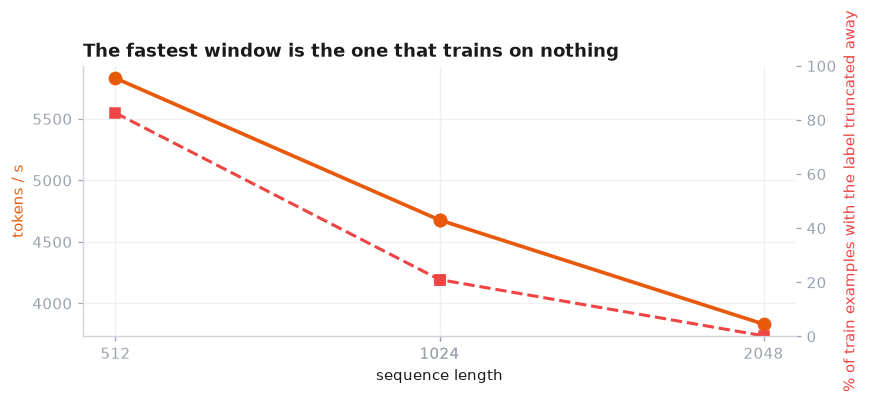

  seq   512  label fully lost:  82.6 %
  seq  1024  label fully lost:  21.0 %
  seq  1024  label fully lost:  21.0 %
  seq  2048  label fully lost:   0.2 %


In [9]:
seq = [(records[r]["config"]["seq_len"], records[r]) for r in records
       if records[r]["config"].get("batch_size") == 8
       and records[r]["status"] == "ok"]
seq.sort(key=lambda t: t[0])

# Coverage from the tokenizer, not from the hardware — the two instruments must be
# read together, which is the point of this figure.
stats = json.loads((REPO / "docs" / "dataset_stats.json").read_text())

fig, ax1 = plt.subplots(figsize=(8, 3.4))
xs = [s for s, _ in seq]
ax1.plot(xs, [d["steady"]["tokens_per_s"] for _, d in seq], "o-", color=ORANGE,
         linewidth=2.4, markersize=8, label="throughput")
ax1.set_xlabel("sequence length"); ax1.set_ylabel("tokens / s", color=ORANGE)
ax1.set_xscale("log", base=2); ax1.set_xticks(xs); ax1.set_xticklabels(xs)

def label_loss(split, sl):
    """% of examples whose ICD codes are truncated away entirely at this window."""
    for e in stats["splits"][split]["truncation"]:
        if e["seq_len"] == sl:
            return e["frac_completion_fully_lost"] * 100
    return None

loss = [label_loss("train", s) for s in xs]
if all(v is not None for v in loss):
    ax2 = ax1.twinx()
    ax2.plot(xs, loss, "s--", color="#EF4444", linewidth=2, markersize=7,
             label="label fully lost")
    ax2.set_ylabel("% of train examples with the label truncated away", color="#EF4444")
    ax2.set_ylim(0, 100); ax2.grid(False)

ax1.set_title("The fastest window is the one that trains on nothing", loc="left",
              fontweight="bold")
plt.tight_layout(); plt.show()

for s, l in zip(xs, loss):
    print(f"  seq {s:5}  label fully lost: {l:5.1f} %")

This is the figure that needs both instruments. The profiler alone selects
`seq_len=512` — it is the fastest. The tokenizer alone cannot see that it is fastest.
Read together: **the fastest configuration is the one that truncates the answer away
from 82.6 % of the training examples**, while the loss curve still looks healthy.

## 6 — Cost

Same workload, list prices, per 1 000 steps. `profiling/analyze.py` carries the rates
and their sources; the CPU rate is a cloud proxy because the measured node is
on-premises and has no list price, and that substitution is recorded in the record
rather than hidden.

In [10]:
cost = {c["run_id"]: c for c in
        json.loads((RESULTS / "analysis.json").read_text())["cost"]["per_run"]}

print(f"{'backend':14}{'$/1k steps':>12}{'excl. queue':>13}")
for label, rid in TRIO.items():
    c = cost[rid]
    print(f"{label:14}{c['usd_per_1000_steps']:12.3f}{c['usd_per_1000_steps_excl_queue']:13.3f}")

g = cost[TRIO["GPU GH200"]]["usd_per_1000_steps"]
t = cost[TRIO["TPU v5e 2x4"]]["usd_per_1000_steps"]
print(f"\nSame step time, {t/g:.1f}x the price: 8 v5e chips against 1 Hopper.")

backend         $/1k steps  excl. queue
CPU 32-core          6.055        6.055
GPU GH200            0.131        0.124
TPU v5e 2x4          1.032        0.651

Same step time, 7.9x the price: 8 v5e chips against 1 Hopper.


## 7 — What this notebook does not show

* **`eval.micro_f1` is null on every record.** `src/evaluate.py` exists and was never
  run — it needs the fine-tuned adapter, which is on a cluster that became
  unreachable. No F1 is reported rather than a fabricated one, and the report says so.
* **No TPU core-utilisation counter exists.** JAX exposes device memory statistics but
  no duty-cycle counter. The TPU column reports HBM occupancy under its own name
  instead of borrowing the CPU/GPU utilisation row.
* **`image_pull_s` is null on the accelerators.** It is measured by the launcher from
  Kubernetes timestamps and was never merged into the record, so registry pull time
  sits inside the wall clock without its own name.

Each of these is a declared gap, carried in `results/analysis.json` under `coverage.gaps`
so the report cannot drift from what the records support.